In [1]:
import json
import pandas as pd
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
root_dir = "../model/new_logs"

In [3]:
def df_to_latex(df):
    df = df.dropna()
    metrics = ['auprc', 'f1', 'mcc']
    for m in metrics:
        df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
        
    return df[metrics].to_latex()

In [4]:
records = {}
for file in glob.glob(f'{root_dir}/**/metadata.json'):
    path = Path(file)
    name = path.parent.stem

    print(name)
    with open(file, 'r') as f:
        data = json.load(f)

    if 'test_metrics' not in data['data']:
        continue
    records[name] = {}
    grouped_data = {}
    finished_folds = 0
    
    for fold in data['data']['test_metrics']:
        if fold == {}:
            continue
        for key, val in fold.items():
            if key not in grouped_data:
                grouped_data[key] = []
                
            grouped_data[key].append(val)
        finished_folds += 1
    for key in grouped_data.keys():
        records[name][f'{key}_avg'] = np.average(grouped_data[key])
        records[name][f'{key}_std'] = np.std(grouped_data[key])
    records[name]['finished_folds'] = finished_folds
    
df = pd.DataFrame.from_dict(records).T

df.sort_values('test_auprc_avg', ascending=False)

finetuning_S_3_perturb2
recycle_T_3_mask_af2_drop_35M_dbptm
finetuning_ST_3_dbptm
finetuning_S_3_perturb3_drop_dbptm
finetuning_Y_3_perturb3_dbptm
uniptm_STY_dbptm
baseline_phos_S
finetuning_T_3_perturb3_dbptm
finetuning_S_3_mask_af2_phos
finetuning_ST_3_mask3_dbptm
recycle_S_3_mask_af2_drop_35M_dbptm
finetuning_S_3_perturb2_recycle_dbptm
finetuning_Y_3_perturb3_reg_dbptm
finetuning_STY_3_mask3_dbptm
finetuning_T_3_perturb2_recycle_dbptm
uniptm_T_dbptm
baseline_STY_uniptm
finetuning_ST_3_perturb3_reg_dbptm
finetuning_T_3
finetuning_STY_3_mask_af2_lm_dbptm
finetuning_STY_3_perturb1_dbptm
baseline_phos_T
finetuning_ST_3_perturb3_drop_dbptm
finetuning_T_3_perturb2_dbptm
finetuning_ST_3_mask_af2_lm_dbptm
recycle_STY_3_mask_af2_drop_35M_dbptm
uniptm_S
finetuning_S_3_perturb3_recycle_dbptm
finetuning_STY_3_mask_af2_dbptm
finetuning_T_3_perturb3_recycle_dbptm
baseline_dbptm_Y
baseline_T_uniptm
finetuning_S_3_perturb3_dbptm
recycle_Y_3_mask_af2_drop_35M_dbptm
finetuning_Y_3_perturb2
baseline_p

,test_auprc_avg,test_auprc_std,test_auroc_avg,test_auroc_std,test_f1_avg,test_f1_std,test_loss_mean_avg,test_loss_mean_std,test_mcc_avg,test_mcc_std,test_precision_avg,test_precision_std,test_recall_avg,test_recall_std,finished_folds
finetuning_Y_3_perturb2_uniptm,0.722214,0.016945,0.898114,0.009425,0.664186,0.016549,0.543651,0.032775,0.620040,0.021668,0.694726,0.042698,0.638406,0.022687,5.0
uniptm_Y_udata,0.682025,0.025796,0.882045,0.010660,0.651528,0.023121,1.243579,0.546216,0.609165,0.029133,0.707702,0.047334,0.605513,0.023239,5.0
baseline_Y_uniptm,0.550136,0.020913,0.836392,0.006012,0.447579,0.012814,0.283989,0.004735,0.439653,0.017294,0.718949,0.033409,0.325161,0.009771,5.0
finetuning_ST_3_dpsp_full,0.529673,0.006857,0.807458,0.002272,0.507959,0.003300,0.683042,0.005388,0.402056,0.006346,0.462485,0.019257,0.565235,0.020655,5.0
finetuning_ST_3_mask_af2_dpsp,0.525559,0.003664,0.806984,0.001972,0.508725,0.002258,0.680057,0.003885,0.402770,0.002692,0.463435,0.004906,0.563998,0.008174,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
recycle_STY_3_mask_af2_drop_dbptm,0.196291,0.017603,0.646006,0.015569,0.198530,0.047253,0.750852,0.008029,0.103240,0.033056,0.228391,0.034846,0.195884,0.090289,3.0
recycle_Y_3_mask_af2_drop_dbptm,0.172757,0.010945,0.539582,0.024295,0.000000,0.000000,0.894004,0.007760,0.021797,0.000693,0.000000,0.000000,0.000000,0.000000,5.0
baseline_STY_uniptm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
recycle_STY_3_mlp_proj_dbptm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


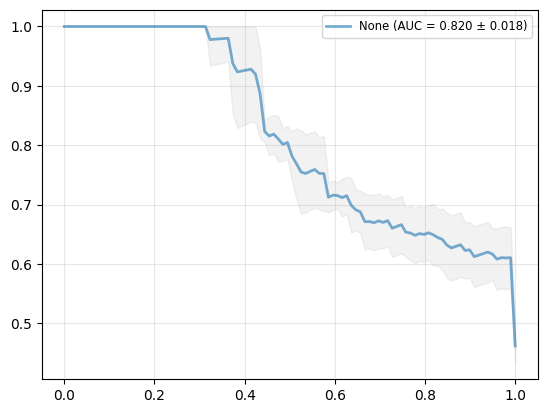

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_multifold_prc(all_labels, all_probs, plot_folds=False, ax=None, color=None, exp_name=None):
    """
    Plots per-fold PRC curves and their mean.
    
    Args:
        all_labels (list of arrays): True binary labels for each fold.
        all_probs (list of arrays): Predicted probabilities for each fold.
    """
    if not ax:
        print('here')
        plt.figure(figsize=(8, 6))
    
    # Define a common set of recall levels for interpolation
    mean_recall = np.linspace(0, 1, 100)
    precisions = []
    aucs = []

    for i, (labels, probs) in enumerate(zip(all_labels, all_probs)):
        precision, recall, _ = precision_recall_curve(labels, probs)
        prc_auc = average_precision_score(labels, probs)
        aucs.append(prc_auc)

        if plot_folds:
            # Plot individual fold (low opacity)
            ax.plot(recall, precision, lw=1, alpha=0.3, 
                    label=f'Fold {i+1} (AUC = {prc_auc:.2f})')

        # Interpolate precision to match the common recall scale
        # We use [::-1] because recall is naturally decreasing in precision_recall_curve
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
        precisions.append(interp_precision)

    # Calculate Mean and Std
    mean_precision = np.mean(precisions, axis=0)
    # Ensure the curve starts at 1 (standard for PR curves)
    #mean_precision[-1] = 0.0 
    mean_auc = np.average(aucs)
    std_auc = np.std(aucs)

    # Plot the Mean Curve (high opacity)
    ax.plot(mean_recall, mean_precision, color=color,
             label=f'{exp_name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
             lw=2, alpha=0.6)

    # Optional: Fill the standard deviation area
    std_precision = np.std(precisions, axis=0)
    precisions_upper = np.minimum(mean_precision + std_precision, 1)
    precisions_lower = np.maximum(mean_precision - std_precision, 0)
    ax.fill_between(mean_recall, precisions_lower, precisions_upper, color='grey' if not color else color, alpha=0.1)

    #ax.set_xlabel('Recall')
    #ax.set_ylabel('Precision')
    #ax.set_title('Multi-fold Precision-Recall Curve')
    ax.legend(fontsize='small', ncol=2)
    ax.grid(alpha=0.3)

# --- Example Usage ---
if __name__ == "__main__":
    # Generating dummy data for 5 folds
    from sklearn.datasets import make_classification
    
    mock_labels = []
    mock_probs = []
    
    for _ in range(5):
        # Create a slightly noisy dataset per fold
        y_true = np.random.randint(0, 2, size=100)
        y_scores = np.random.uniform(0, 1, size=100)
        # Shift scores to simulate actual predictive power
        y_scores = np.where(y_true == 1, y_scores + 0.2, y_scores - 0.2)
        y_scores = np.clip(y_scores, 0, 1)
        
        mock_labels.append(y_true)
        mock_probs.append(y_scores)
    fig, ax = plt.subplots()
    plot_multifold_prc(mock_labels, mock_probs, ax=ax)

In [13]:
exp_name = 'finetuning_STY_3_perturb2_dbptm'
fold_preds = []
fold_labels = []
for file in glob.glob(f'{root_dir}/{exp_name}/*/test_preds*.json'):
    data = pd.read_json(file)
    fold_preds.append(np.concatenate(data.logits.to_numpy()))
    fold_labels.append(np.concatenate(data.labels.to_numpy())) 

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [52]:
plot_multifold_prc(fold_labels, list(map(sigmoid, fold_preds)))

AttributeError: 'NoneType' object has no attribute 'plot'

<Figure size 800x600 with 0 Axes>

In [9]:
def graph_auprc(root_dir, exp_name, exp_label, ax, color):
    fold_preds = []
    fold_labels = []
    for file in glob.glob(f'{root_dir}/{exp_name}/*/test_preds*.json'):
        data = pd.read_json(file)
        fold_preds.append(np.concatenate(data.logits.to_numpy()))
        fold_labels.append(np.concatenate(data.labels.to_numpy())) 
    
    plot_multifold_prc(fold_labels, list(map(sigmoid, fold_preds)), ax=ax, color=color, exp_name=exp_label)


In [13]:
from matplotlib import colormaps
def graph_experiments(root_dir, exp_list, residues=['S', 'T', 'Y', 'ST', 'STY'], dataset='dbPTM'):
    fig, axs = plt.subplots()
    
    axs.set_title(f'{dataset} Interpolated Precision-Recall Curves')
    cmap = colormaps['plasma']
    for i, residue in enumerate(residues):
        for  (prefix, postfix, label_prefix) in exp_list:
            color = cmap((i + 1)/len(residues))
            exp_name = f'{prefix}_{residue}'
            if len(postfix) > 0:
                exp_name += f'_{postfix}'
            label = f'{label_prefix} {residue}'
            graph_auprc(root_dir, exp_name, label, axs, color=color)
    fig.set_size_inches(8, 6)
    plt.show()
    

In [14]:
import os
os.getcwd()

'/auto/brno12-cerit/nfs4/home/nexuso1/phossil/notebooks'

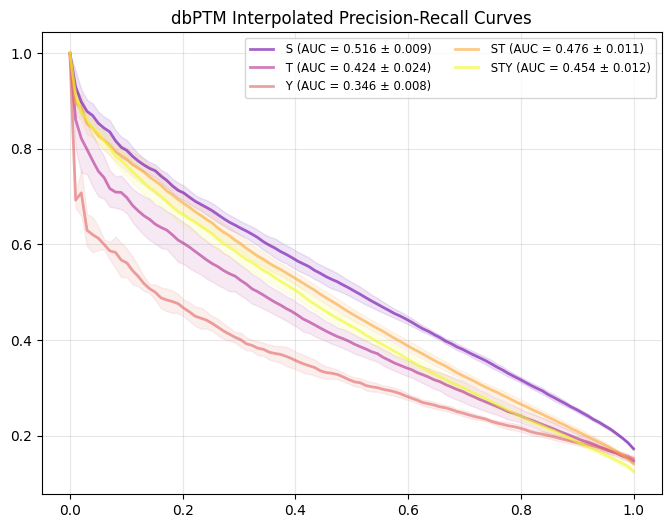

TypeError: cannot unpack non-iterable NoneType object

In [15]:
root_dir = '/auto/brno12-cerit/nfs4/home/nexuso1/phossil/model/new_logs'
fig, ax = graph_experiments(root_dir, [('finetuning', '3_mask_af2_dbptm', '')], dataset='dbPTM')
fig.show()

In [9]:
print(df_to_latex(df[['dpsp' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
finetuning\_ST\_3\_dpsp\_full       &  0.530 pm 0.007 &  0.508 pm 0.003 &  0.402 pm 0.006 \\
finetuning\_ST\_3\_mask\_af2\_dpsp   &  0.526 pm 0.004 &  0.509 pm 0.002 &  0.403 pm 0.003 \\
finetuning\_ST\_3\_dpsp\_full\_pert2 &  0.524 pm 0.002 &  0.506 pm 0.001 &  0.398 pm 0.002 \\
baseline\_ST\_dpsp                &  0.467 pm 0.001 &  0.313 pm 0.002 &  0.311 pm 0.001 \\
finetuning\_Y\_3\_mask\_af2\_dpsp    &  0.465 pm 0.005 &  0.453 pm 0.006 &  0.285 pm 0.009 \\
finetuning\_Y\_3\_dpsp\_full\_pert2  &  0.463 pm 0.008 &  0.453 pm 0.006 &  0.285 pm 0.010 \\
finetuning\_Y\_3\_dpsp\_full        &  0.461 pm 0.007 &  0.450 pm 0.005 &  0.286 pm 0.004 \\
baseline\_Y\_dpsp                 &  0.426 pm 0.001 &  0.207 pm 0.007 &  0.213 pm 0.004 \\
\bottomrule
\end{tabular}



/var/tmp/pbs.19306073.pbs-m1.metacentrum.cz/ipykernel_912046/2589722336.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df[metrics].to_latex()


In [26]:
print(df_to_latex(df[['uniptm' in x and not 'dbptm' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
finetuning\_Y\_3\_perturb2\_uniptm &  0.722 pm 0.017 &  0.664 pm 0.017 &  0.620 pm 0.022 \\
uniptm\_Y\_udata                 &  0.682 pm 0.026 &  0.652 pm 0.023 &  0.609 pm 0.029 \\
baseline\_Y\_uniptm              &  0.550 pm 0.021 &  0.448 pm 0.013 &  0.440 pm 0.017 \\
finetuning\_T\_3\_perturb2\_uniptm &  0.483 pm 0.023 &  0.492 pm 0.016 &  0.455 pm 0.017 \\
uniptm\_T\_udata                 &  0.452 pm 0.022 &  0.485 pm 0.009 &  0.450 pm 0.011 \\
finetuning\_S\_3\_perturb2\_uniptm &  0.414 pm 0.017 &  0.444 pm 0.015 &  0.389 pm 0.016 \\
uniptm\_S\_udata                 &  0.399 pm 0.019 &  0.441 pm 0.012 &  0.385 pm 0.011 \\
uniptm\_S                       &  0.368 pm 0.012 &  0.400 pm 0.010 &  0.311 pm 0.007 \\
baseline\_T\_uniptm              &  0.364 pm 0.014 &  0.214 pm 0.018 &  0.275 pm 0.010 \\
baseline\_S\_uniptm              &  0.358 pm 0.015 &  0.187 pm 0.014 &  0.230 pm 0.01

/var/tmp/pbs.19306073.pbs-m1.metacentrum.cz/ipykernel_912046/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19306073.pbs-m1.metacentrum.cz/ipykernel_912046/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19306073.pbs-m1.metacentrum.cz/ipykernel_912046/2589722

In [7]:
print(df_to_latex(df[[x.endswith('_dbptm') for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
finetuning\_S\_3\_drop\_reg\_dbptm           &  0.523 pm 0.012 &  0.513 pm 0.007 &  0.400 pm 0.011 \\
finetuning\_S\_3\_dbptm                    &  0.523 pm 0.011 &  0.514 pm 0.008 &  0.403 pm 0.013 \\
finetuning\_S\_3\_mask\_af2\_drop\_dbptm      &  0.519 pm 0.011 &  0.510 pm 0.008 &  0.395 pm 0.012 \\
finetuning\_S\_3\_mask\_af2\_dbptm           &  0.516 pm 0.009 &  0.508 pm 0.005 &  0.395 pm 0.007 \\
finetuning\_S\_3\_perturb2\_reg\_dbptm       &  0.513 pm 0.016 &  0.509 pm 0.012 &  0.395 pm 0.016 \\
finetuning\_S\_3\_perturb1\_reg\_dbptm       &  0.512 pm 0.012 &  0.506 pm 0.007 &  0.390 pm 0.010 \\
finetuning\_S\_3\_perturb3\_drop\_dbptm      &  0.512 pm 0.014 &  0.504 pm 0.011 &  0.386 pm 0.015 \\
finetuning\_S\_3\_perturb3\_dbptm           &  0.510 pm 0.011 &  0.503 pm 0.006 &  0.387 pm 0.008 \\
finetuning\_S\_3\_perturb2\_dbptm           &  0.510 pm 0.012 &  0.505 pm 0.010 &  0.3

/var/tmp/pbs.19325548.pbs-m1.metacentrum.cz/ipykernel_801350/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19325548.pbs-m1.metacentrum.cz/ipykernel_801350/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19325548.pbs-m1.metacentrum.cz/ipykernel_801350/2589722

In [9]:
print(df_to_latex(df[[x.endswith('_dbptm') and ('perturb' in x or 'mask' in x) and '_S_' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
finetuning\_S\_3\_mask\_af2\_drop\_dbptm    &  0.519 pm 0.011 &  0.510 pm 0.008 &  0.395 pm 0.012 \\
finetuning\_S\_3\_mask\_af2\_dbptm         &  0.516 pm 0.009 &  0.508 pm 0.005 &  0.395 pm 0.007 \\
finetuning\_S\_3\_perturb2\_reg\_dbptm     &  0.513 pm 0.016 &  0.509 pm 0.012 &  0.395 pm 0.016 \\
finetuning\_S\_3\_perturb1\_reg\_dbptm     &  0.512 pm 0.012 &  0.506 pm 0.007 &  0.390 pm 0.010 \\
finetuning\_S\_3\_perturb3\_drop\_dbptm    &  0.512 pm 0.014 &  0.504 pm 0.011 &  0.386 pm 0.015 \\
finetuning\_S\_3\_perturb3\_dbptm         &  0.510 pm 0.011 &  0.503 pm 0.006 &  0.387 pm 0.008 \\
finetuning\_S\_3\_perturb2\_dbptm         &  0.510 pm 0.012 &  0.505 pm 0.010 &  0.389 pm 0.013 \\
finetuning\_S\_3\_perturb1\_dbptm         &  0.509 pm 0.022 &  0.505 pm 0.014 &  0.391 pm 0.018 \\
finetuning\_S\_3\_mask3\_dbptm            &  0.509 pm 0.012 &  0.505 pm 0.007 &  0.390 pm 0.010 \\
fin

/var/tmp/pbs.19325548.pbs-m1.metacentrum.cz/ipykernel_801350/2589722336.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df[metrics].to_latex()


In [5]:
print(df_to_latex(df[[x.endswith('_dbptm') and 'uniptm' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
uniptm\_S\_dbptm   &  0.495 pm 0.007 &  0.494 pm 0.007 &  0.375 pm 0.010 \\
uniptm\_ST\_dbptm  &  0.454 pm 0.009 &  0.465 pm 0.007 &  0.368 pm 0.008 \\
uniptm\_STY\_dbptm &  0.432 pm 0.008 &  0.445 pm 0.005 &  0.359 pm 0.005 \\
uniptm\_T\_dbptm   &  0.388 pm 0.015 &  0.423 pm 0.011 &  0.310 pm 0.009 \\
uniptm\_Y\_dbptm   &  0.350 pm 0.004 &  0.386 pm 0.003 &  0.259 pm 0.005 \\
\bottomrule
\end{tabular}



/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df[metrics].to_latex()


In [6]:
print(df_to_latex(df[[x.endswith('_dbptm') and 'uniptm' and 'STY' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
finetuning\_STY\_3\_dbptm                  &  0.458 pm 0.011 &  0.461 pm 0.006 &  0.381 pm 0.008 \\
finetuning\_STY\_3\_drop\_reg\_dbptm         &  0.455 pm 0.011 &  0.461 pm 0.005 &  0.377 pm 0.005 \\
finetuning\_STY\_3\_mask\_af2\_dbptm         &  0.454 pm 0.012 &  0.459 pm 0.007 &  0.375 pm 0.006 \\
finetuning\_STY\_3\_perturb1\_dbptm         &  0.453 pm 0.007 &  0.458 pm 0.007 &  0.371 pm 0.007 \\
finetuning\_STY\_3\_mask\_af2\_drop\_dbptm    &  0.451 pm 0.010 &  0.458 pm 0.004 &  0.373 pm 0.003 \\
finetuning\_STY\_3\_perturb3\_drop\_dbptm    &  0.449 pm 0.010 &  0.452 pm 0.004 &  0.366 pm 0.004 \\
finetuning\_STY\_3\_perturb3\_dbptm         &  0.447 pm 0.009 &  0.456 pm 0.005 &  0.371 pm 0.005 \\
finetuning\_STY\_3\_perturb3\_reg\_dbptm     &  0.446 pm 0.006 &  0.455 pm 0.002 &  0.370 pm 0.002 \\
finetuning\_STY\_3\_mask\_af2\_lm\_dbptm      &  0.446 pm 0.009 &  0.452 pm 0.005 &  0.

/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722

In [7]:
print(df_to_latex(df[[x.endswith('_dbptm') and 'uniptm' and '_Y' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
uniptm\_Y\_dbptm                        &  0.350 pm 0.004 &  0.386 pm 0.003 &  0.259 pm 0.005 \\
finetuning\_Y\_3\_perturb3\_reg\_dbptm     &  0.348 pm 0.008 &  0.387 pm 0.014 &  0.262 pm 0.012 \\
finetuning\_Y\_3\_mask\_af2\_drop\_dbptm    &  0.347 pm 0.012 &  0.384 pm 0.008 &  0.263 pm 0.013 \\
finetuning\_Y\_3\_mask\_af2\_dbptm         &  0.346 pm 0.008 &  0.379 pm 0.013 &  0.257 pm 0.011 \\
finetuning\_Y\_3\_perturb3\_drop\_dbptm    &  0.346 pm 0.009 &  0.388 pm 0.005 &  0.262 pm 0.005 \\
finetuning\_Y\_3\_perturb1\_dbptm         &  0.344 pm 0.009 &  0.391 pm 0.009 &  0.267 pm 0.011 \\
finetuning\_Y\_3\_mask\_af2\_lm\_dbptm      &  0.343 pm 0.011 &  0.374 pm 0.013 &  0.254 pm 0.015 \\
finetuning\_Y\_3\_mask3\_dbptm            &  0.341 pm 0.010 &  0.371 pm 0.016 &  0.255 pm 0.014 \\
finetuning\_Y\_3\_perturb3\_dbptm         &  0.341 pm 0.009 &  0.379 pm 0.012 &  0.253 pm 0.016 \\
fine

/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df[metrics].to_latex()


In [8]:
print(df_to_latex(df[[x.endswith('_dbptm') and '_T' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
finetuning\_T\_3\_drop\_reg\_dbptm         &  0.426 pm 0.017 &  0.441 pm 0.011 &  0.338 pm 0.012 \\
finetuning\_T\_3\_dbptm                  &  0.425 pm 0.016 &  0.443 pm 0.010 &  0.339 pm 0.009 \\
finetuning\_T\_3\_mask\_af2\_dbptm         &  0.424 pm 0.024 &  0.441 pm 0.013 &  0.335 pm 0.014 \\
finetuning\_T\_3\_mask\_af2\_drop\_dbptm    &  0.422 pm 0.015 &  0.438 pm 0.013 &  0.329 pm 0.013 \\
finetuning\_T\_3\_perturb2\_dbptm         &  0.419 pm 0.020 &  0.435 pm 0.014 &  0.324 pm 0.015 \\
finetuning\_T\_3\_perturb1\_reg\_dbptm     &  0.418 pm 0.023 &  0.434 pm 0.013 &  0.326 pm 0.014 \\
finetuning\_T\_3\_perturb3\_drop\_dbptm    &  0.418 pm 0.022 &  0.436 pm 0.012 &  0.326 pm 0.012 \\
finetuning\_T\_3\_perturb2\_reg\_dbptm     &  0.417 pm 0.023 &  0.433 pm 0.013 &  0.323 pm 0.013 \\
finetuning\_T\_3\_perturb3\_reg\_dbptm     &  0.417 pm 0.021 &  0.434 pm 0.013 &  0.325 pm 0.015 \\
fi

/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return df[metrics].to_latex()


In [10]:
print(df_to_latex(df[['baseline' in x for x in df.index]].sort_values('test_auprc_avg', ascending=False)))

\begin{tabular}{llll}
\toprule
{} &           auprc &              f1 &             mcc \\
\midrule
baseline\_Y\_uniptm  &  0.550 pm 0.021 &  0.448 pm 0.013 &  0.440 pm 0.017 \\
baseline\_ST\_dpsp   &  0.467 pm 0.001 &  0.313 pm 0.002 &  0.311 pm 0.001 \\
baseline\_dbptm\_S   &  0.467 pm 0.005 &  0.304 pm 0.006 &  0.294 pm 0.005 \\
baseline\_Y\_dpsp    &  0.426 pm 0.001 &  0.207 pm 0.007 &  0.213 pm 0.004 \\
baseline\_dbptm\_ST  &  0.418 pm 0.012 &  0.244 pm 0.008 &  0.263 pm 0.005 \\
baseline\_dbptm\_STY &  0.395 pm 0.011 &  0.226 pm 0.009 &  0.254 pm 0.010 \\
baseline\_dbptm\_T   &  0.372 pm 0.021 &  0.152 pm 0.011 &  0.189 pm 0.014 \\
baseline\_T\_uniptm  &  0.364 pm 0.014 &  0.214 pm 0.018 &  0.275 pm 0.010 \\
baseline\_S\_uniptm  &  0.358 pm 0.015 &  0.187 pm 0.014 &  0.230 pm 0.011 \\
baseline\_phos\_S    &  0.351 pm 0.017 &  0.186 pm 0.010 &  0.222 pm 0.013 \\
baseline\_dbptm\_Y   &  0.326 pm 0.011 &  0.065 pm 0.008 &  0.124 pm 0.015 \\
baseline\_phos\_Y    &  0.308 pm 0.013 &  

/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[m] = df.apply(lambda row: f"{row[f'test_{m}_avg']:.3f} pm {row[f'test_{m}_std']:.3f}", axis=1)
/var/tmp/pbs.19326970.pbs-m1.metacentrum.cz/ipykernel_978879/2589722